## **Lab 1: Face Recognition and PCA Lab**

#### Samantha Retsos - smr22f@fsu.edu

Step 1 - Importing Libraries

In [1]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import random

Step 2 - Defining the Constants and Paths

In [2]:
# paths
IMAGE_DIR = r"D:\AT&TDatabase"

# constants
IMG_HEIGHT = 112
IMG_WIDTH = 92
TOTAL_PIXELS = IMG_HEIGHT * IMG_WIDTH
NUM_SUBJECTS = 40

Step 3 - Loading Images

In [3]:
def load_images(start_train=3, end_train=6, start_test=1, end_test=2, start_gallery=7, end_gallery=10, num_subjects=NUM_SUBJECTS):
    train_data = []
    test_data = []
    gallery_data = []

    for subject in range(1, num_subjects + 1):
        # load training images
        for img_num in range(start_train, end_train + 1):
            img_path = os.path.join(IMAGE_DIR, f"s{subject}/{img_num}.pgm")
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:  # check for loading error
                print(f"image not found: {img_path}")
                continue
            img_vector = img.flatten()
            train_data.append(img_vector)

        # load testing images
        for img_num in range(start_test, end_test + 1):
            img_path = os.path.join(IMAGE_DIR, f"s{subject}/{img_num}.pgm")
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:  # check for loading error
                print(f"image not found: {img_path}")
                continue
            img_vector = img.flatten()
            test_data.append(img_vector)

        # load gallery images
        for img_num in range(start_gallery, end_gallery + 1):
            img_path = os.path.join(IMAGE_DIR, f"s{subject}/{img_num}.pgm")
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:  # check for loading error
                print(f"image not found: {img_path}")
                continue
            img_vector = img.flatten()
            gallery_data.append(img_vector)

    return np.array(train_data).T, np.array(test_data).T, np.array(gallery_data).T  # return as (num_pixels, num_images)

# load datasets
train_data, test_data, gallery_data = load_images()

print(f"train data shape: {train_data.shape}")  # should be (10304, 400)
print(f"test data shape: {test_data.shape}")    # should be (10304, 100)
print(f"gallery data shape: {gallery_data.shape}")  # should be (10304, 400)


train data shape: (10304, 160)
test data shape: (10304, 80)
gallery data shape: (10304, 160)


Step 4 - PCA

In [4]:
# compute average face
mean_face = np.mean(train_data, axis=1).reshape(-1, 1)

# mean-center datasets
train_data_centered = train_data - mean_face
test_data_centered = test_data - mean_face  # use train mean
gallery_data_centered = gallery_data - mean_face  # use train mean

# covariance matrix
cov_matrix = np.dot(train_data_centered.T, train_data_centered)

# eigenvalues and eigenvectors
eigenvalues, eigenvectors_small = np.linalg.eigh(cov_matrix)

# sort eigenvectors by eigenvalues
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors_small = eigenvectors_small[:, sorted_indices]

# project to PCA space
eigenvectors = np.dot(train_data_centered, eigenvectors_small)

# normalize eigenvectors
eigenvectors = eigenvectors / (np.linalg.norm(eigenvectors, axis=0) + 1e-10)

# create PCA space
k = 50  # number of components
eigenvectors_k = eigenvectors[:, :k]

# project test and gallery data
train_proj = np.dot(eigenvectors_k.T, train_data_centered)
test_proj = np.dot(eigenvectors_k.T, test_data_centered)
gallery_proj = np.dot(eigenvectors_k.T, gallery_data_centered)

# compute the covariance of the projected gallery set
cov_matrix_proj = np.cov(gallery_proj)

# invert the covariance matrix for Mahalanobis distance
inv_cov_matrix = np.linalg.inv(cov_matrix_proj)

# compute the distance matrix using Mahalanobis distance
distance_matrix_mahalanobis = cdist(test_proj.T, gallery_proj.T, metric='mahalanobis', VI=inv_cov_matrix)

# find matches
correct_matches = 0
for test_idx in range(test_proj.shape[1]):
    min_idx = np.argmin(distance_matrix_mahalanobis[test_idx])
    test_subject = test_idx // 2 + 1  # each subject has 2 test images
    gallery_subject = min_idx // 4 + 1  # each subject has 4 gallery images
    if test_subject == gallery_subject:
        correct_matches += 1

# compute accuracy
accuracy = correct_matches / test_proj.shape[1]
print(f"identification accuracy: {accuracy * 100:.2f}%")

identification accuracy: 87.50%


Step 5 - Visualization Process

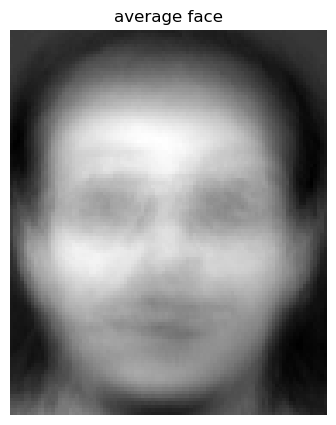

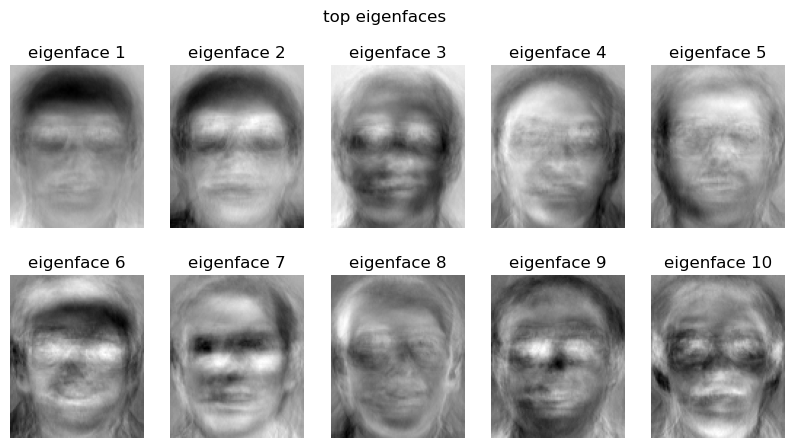

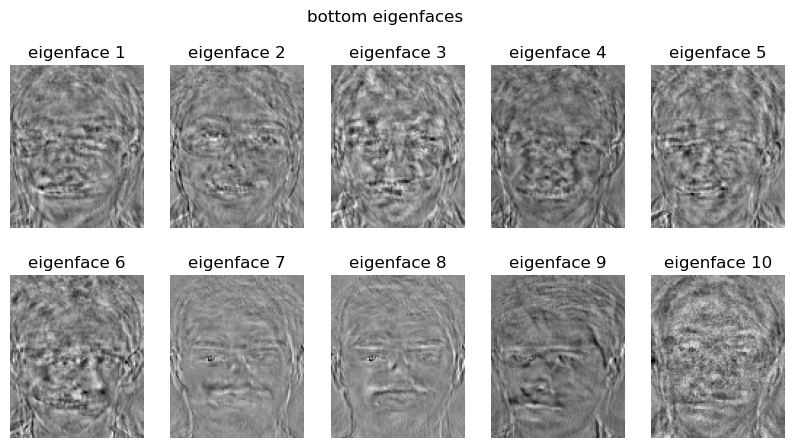

In [5]:
# show average face
plt.figure(figsize=(5, 5))
plt.imshow(mean_face.reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
plt.title("average face")
plt.axis('off')
plt.show()

# show top 10 eigenfaces
def plot_eigenfaces(eigenvectors, num_faces=10, title=""):
    plt.figure(figsize=(10, 5))
    for i in range(num_faces):
        plt.subplot(2, 5, i + 1)
        plt.imshow(eigenvectors[:, i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
        plt.title(f"eigenface {i+1}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

plot_eigenfaces(eigenvectors[:, :10], title="top eigenfaces")  # top 10 eigenfaces

# show bottom 10 eigenfaces
plot_eigenfaces(eigenvectors[:, -10:], title="bottom eigenfaces")  # bottom 10 eigenfaces

Step 6 - Random Images

randomly selected subjects: [11, 17]


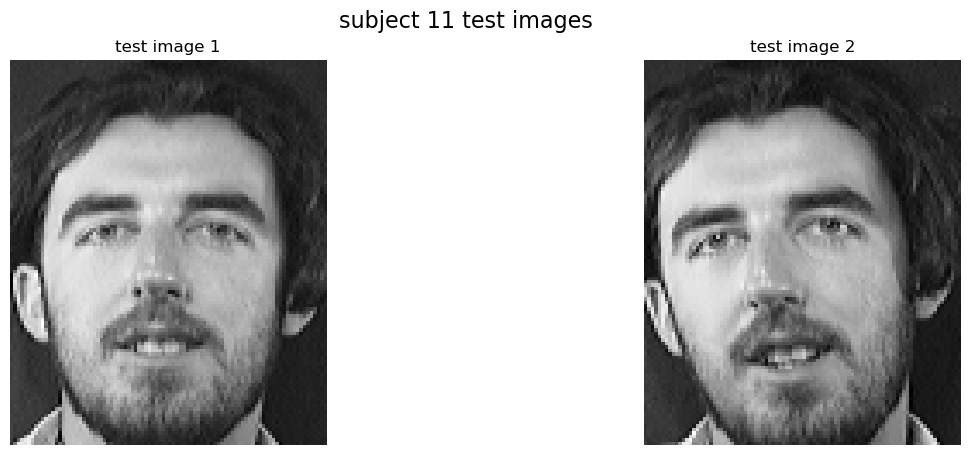

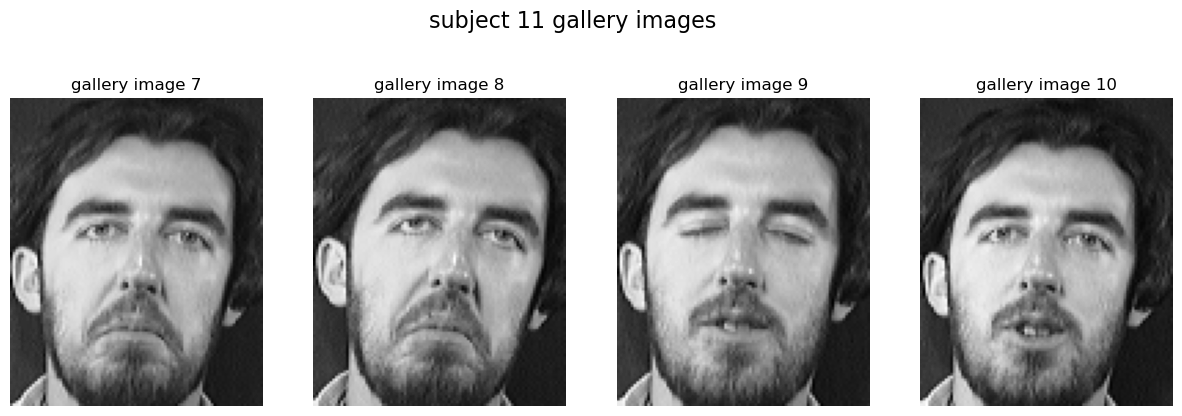

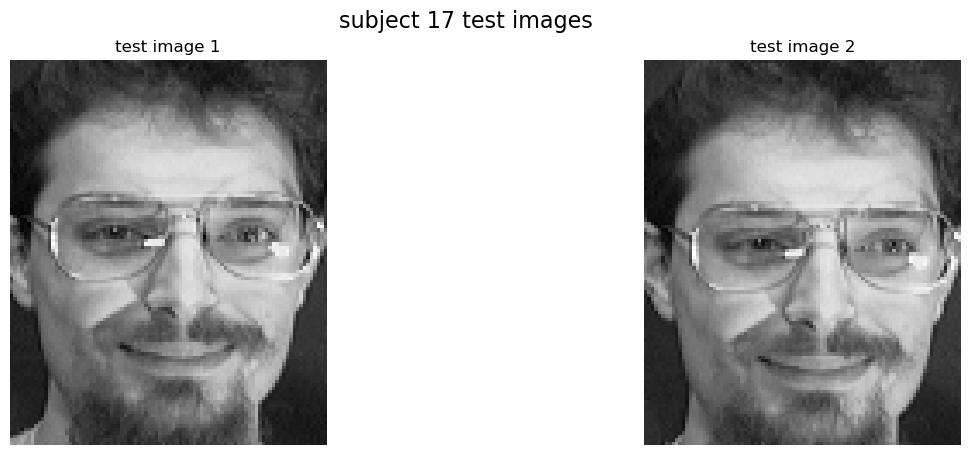

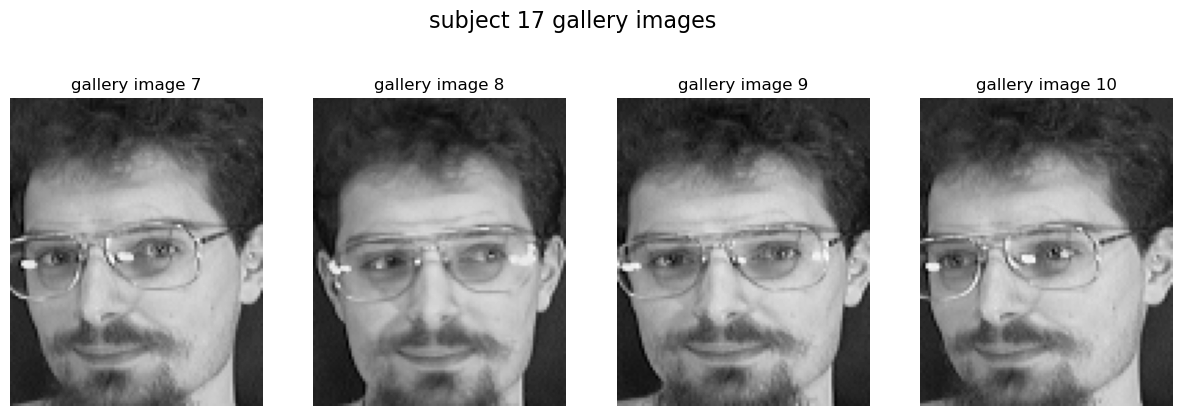

In [6]:
def show_images(subjects, start_test, end_test, start_gallery, end_gallery):
    for subject in subjects:
        # create subplots for test images
        fig, axs = plt.subplots(1, end_test-start_test+1, figsize=(15, 5))
        fig.suptitle(f"subject {subject} test images", fontsize=16)

        for img_num, ax in zip(range(start_test, end_test+1), axs):
            img_path = os.path.join(IMAGE_DIR, f"s{subject}/{img_num}.pgm")
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            ax.imshow(img, cmap='gray')  # display image in grayscale
            ax.set_title(f"test image {img_num}")  # title for test images
            ax.axis('off')  # turn off axis

        plt.show()  # display test images

        # create subplots for gallery images
        fig, axs = plt.subplots(1, end_gallery-start_gallery+1, figsize=(15, 5))
        fig.suptitle(f"subject {subject} gallery images", fontsize=16)

        for img_num, ax in zip(range(start_gallery, end_gallery+1), axs):
            img_path = os.path.join(IMAGE_DIR, f"s{subject}/{img_num}.pgm")
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            ax.imshow(img, cmap='gray')  # display image in grayscale
            ax.set_title(f"gallery image {img_num}")  # title for gallery images
            ax.axis('off')  # turn off axis

        plt.show()  # display gallery images

# select random subjects and show their images
random_subjects = random.sample(range(1, NUM_SUBJECTS + 1), 2)
print(f"randomly selected subjects: {random_subjects}")
show_images(random_subjects, 1, 2, 7, 10)  # show test images 1 to 2 and gallery images 7 to 10


Step 7 - Matches    

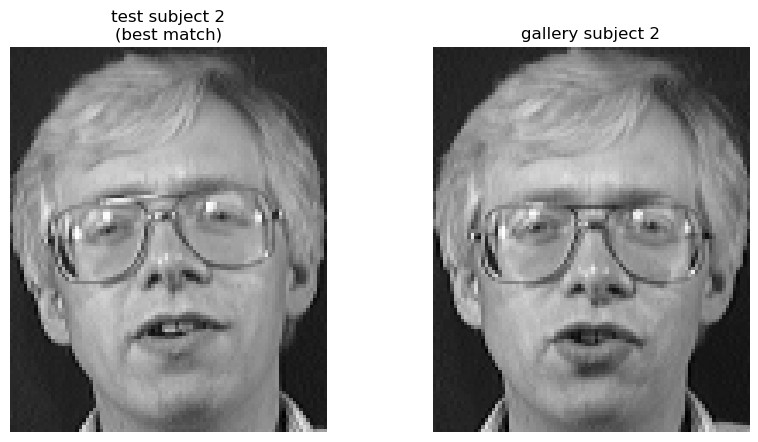

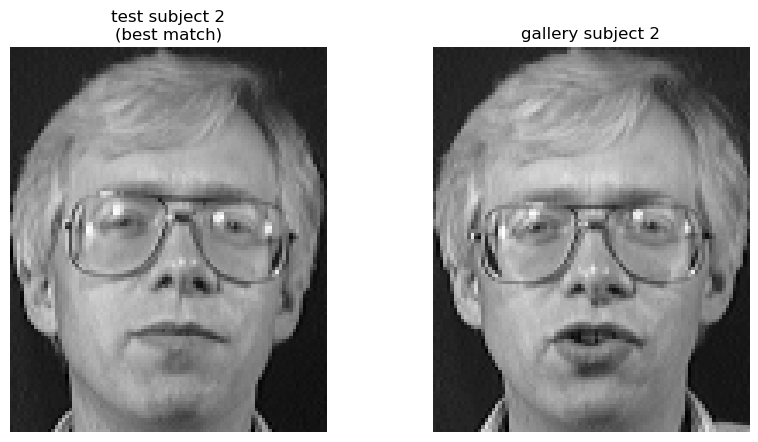

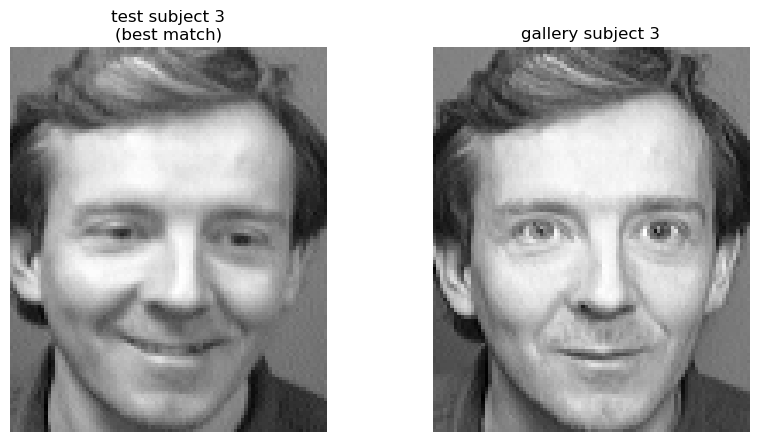

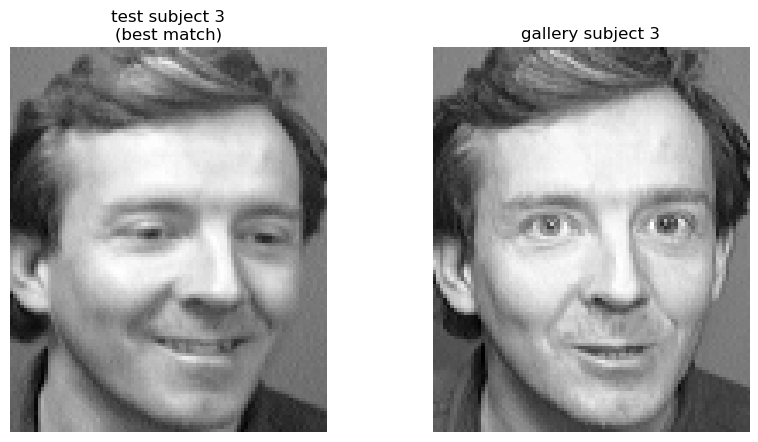

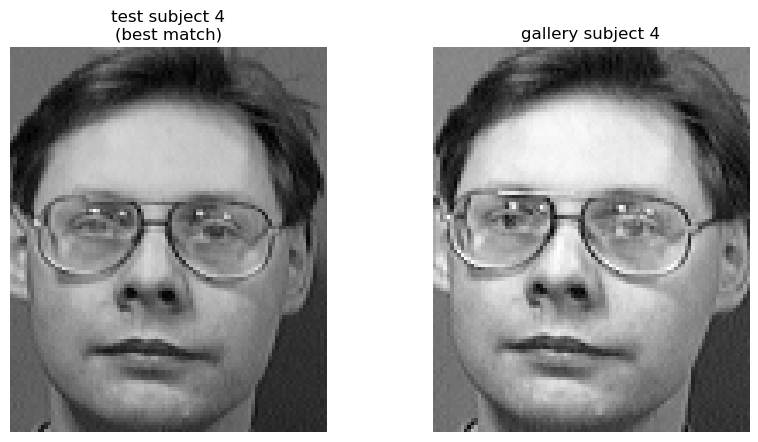

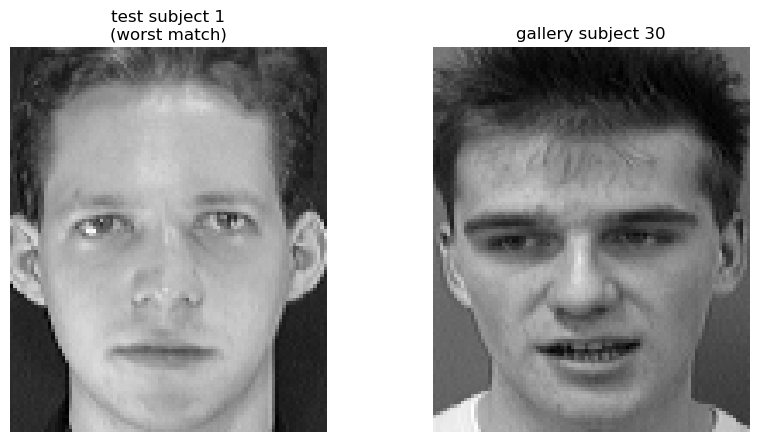

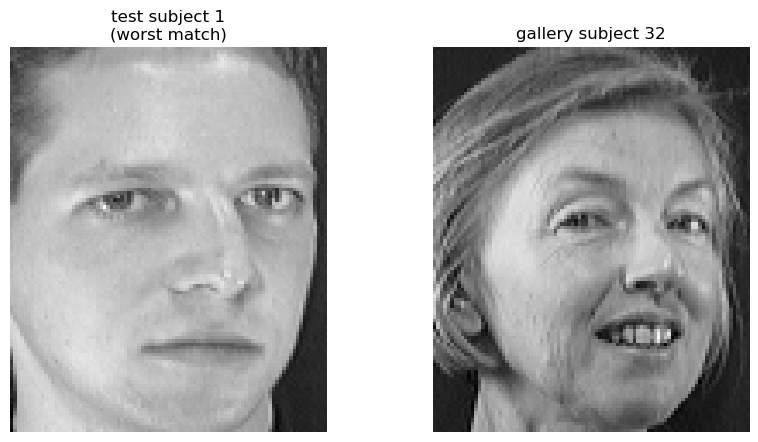

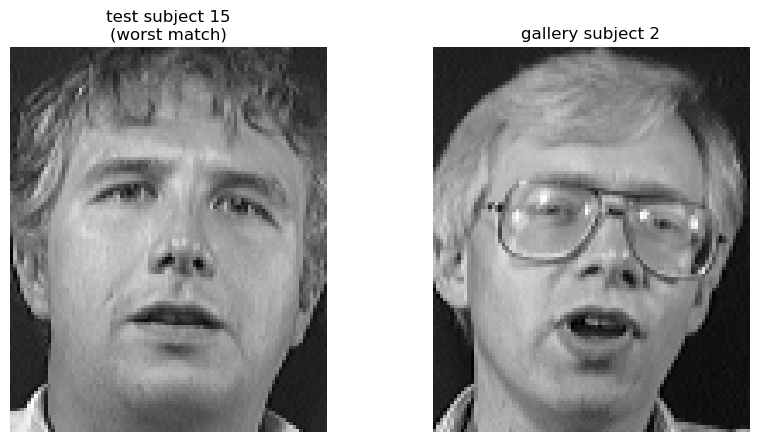

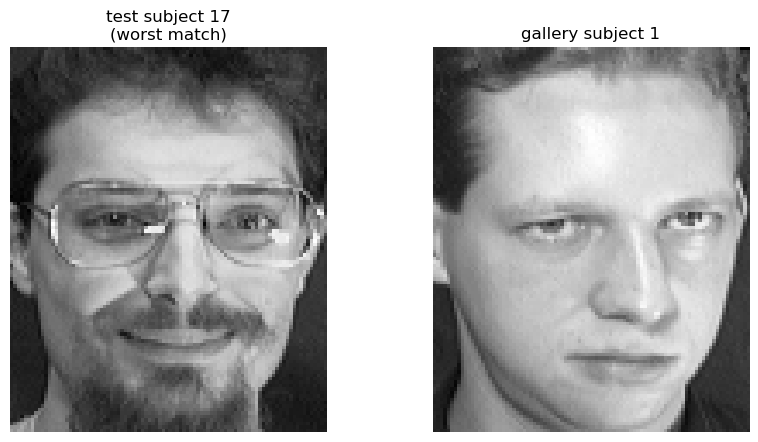

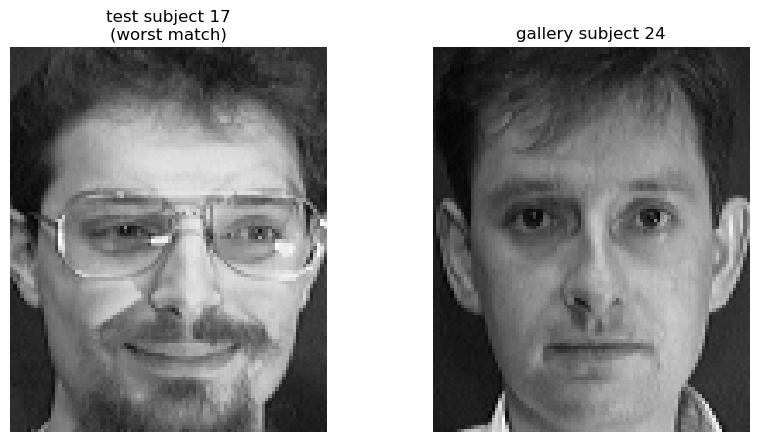

In [7]:
distance_matrix = cdist(test_proj.T, gallery_proj.T, metric='mahalanobis', VI=inv_cov_matrix)

def show_matches(test_proj, gallery_proj, distance_matrix, correct=True): 
    matches = []
    for test_idx in range(test_proj.shape[1]):
        min_idx = np.argmin(distance_matrix[test_idx])  # find closest gallery image
        test_subject = test_idx // 2 + 1  # determine test subject
        gallery_subject = min_idx // 4 + 1  # determine gallery subject
        
        # check if it's a correct or incorrect match
        if (correct and test_subject == gallery_subject) or (not correct and test_subject != gallery_subject):
            matches.append((test_idx, min_idx, test_subject, gallery_subject))
        if len(matches) >= 5:  # show up to 5 matches
            break
    
    for match in matches:
        test_idx, min_idx, test_subject, gallery_subject = match
        
        # construct file paths for test and gallery images
        test_img_path = os.path.join(IMAGE_DIR, f"s{test_subject}/{(test_idx % 2) + 1}.pgm")
        gallery_img_path = os.path.join(IMAGE_DIR, f"s{gallery_subject}/{(min_idx % 4) + 7}.pgm")

        test_img = cv2.imread(test_img_path, cv2.IMREAD_GRAYSCALE)  # load test image
        gallery_img = cv2.imread(gallery_img_path, cv2.IMREAD_GRAYSCALE)  # load gallery image
        
        # display test and gallery images side by side
        fig, axs = plt.subplots(1, 2, figsize=(10, 5))
        axs[0].imshow(test_img, cmap='gray')
        axs[0].set_title(f"test subject {test_subject}\n(best match)" if correct else f"test subject {test_subject}\n(worst match)")
        axs[0].axis('off')
        axs[1].imshow(gallery_img, cmap='gray')
        axs[1].set_title(f"gallery subject {gallery_subject}")
        axs[1].axis('off')
        plt.show()

# call function for correct and incorrect matches
show_matches(test_proj, gallery_proj, distance_matrix, correct=True)  # display correct matches
show_matches(test_proj, gallery_proj, distance_matrix, correct=False)  # display incorrect matches

Step 8 - Eigenvalue Counts

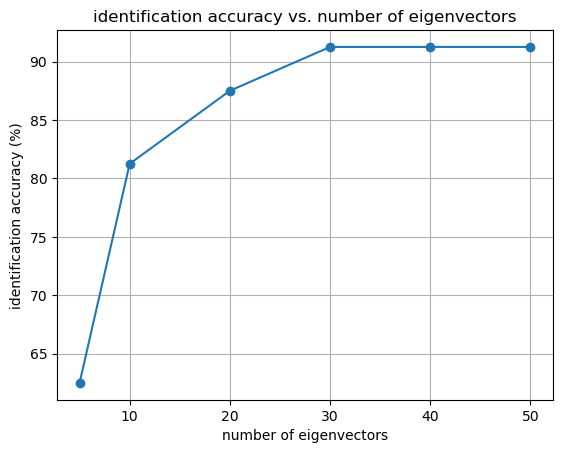

In [8]:
def experiment_with_eigenvectors():
    eigenvector_counts = [5, 10, 20, 30, 40, 50]  # different numbers of eigenvectors
    accuracies = []  # list to store accuracies
    
    for k in eigenvector_counts:
        eigenvectors_k = eigenvectors[:, :k]  # select top k eigenvectors
        # project data onto PCA space
        test_proj_k = np.dot(eigenvectors_k.T, test_data_centered)
        gallery_proj_k = np.dot(eigenvectors_k.T, gallery_data_centered)
        # compute distance matrix
        distance_matrix_k = cdist(test_proj_k.T, gallery_proj_k.T, metric='euclidean')
        
        correct_matches_k = 0  # counter for correct matches
        for test_idx in range(test_proj_k.shape[1]):
            min_idx = np.argmin(distance_matrix_k[test_idx])  # find closest gallery image
            test_subject = test_idx // 2 + 1  # determine test subject
            gallery_subject = min_idx // 4 + 1  # determine gallery subject
            if test_subject == gallery_subject:  # check for a correct match
                correct_matches_k += 1

        accuracy_k = correct_matches_k / test_proj_k.shape[1]  # compute accuracy
        accuracies.append(accuracy_k * 100)  # store accuracy as percentage

    # plot accuracy vs number of eigenvectors
    plt.plot(eigenvector_counts, accuracies, marker='o')
    plt.title("identification accuracy vs. number of eigenvectors")
    plt.xlabel("number of eigenvectors")
    plt.ylabel("identification accuracy (%)")
    plt.grid(True)
    plt.show()

experiment_with_eigenvectors()

Step 9 - Dataset Splits

In [9]:
def different_split_experiment():
    # load datasets with specified image ranges
    train_data_new, test_data_new, gallery_data_new = load_images(start_train=1, end_train=4, start_test=9, end_test=10, start_gallery=5, end_gallery=8)

    # compute average face
    mean_face_new = np.mean(train_data_new, axis=1).reshape(-1, 1)
    # mean-center datasets
    train_data_centered_new = train_data_new - mean_face_new
    test_data_centered_new = test_data_new - mean_face_new
    gallery_data_centered_new = gallery_data_new - mean_face_new

    # covariance matrix
    cov_matrix_new = np.dot(train_data_centered_new.T, train_data_centered_new)
    # eigenvalues and eigenvectors
    eigenvalues_new, eigenvectors_small_new = np.linalg.eigh(cov_matrix_new)
    # sort eigenvectors
    sorted_indices_new = np.argsort(eigenvalues_new)[::-1]
    eigenvectors_new = np.dot(train_data_centered_new, eigenvectors_small_new[:, sorted_indices_new])
    # normalize eigenvectors
    eigenvectors_new = eigenvectors_new / (np.linalg.norm(eigenvectors_new, axis=0) + 1e-10)
    eigenvectors_k_new = eigenvectors_new[:, :50]  # use 50 eigenvectors

    # project test and gallery data
    test_proj_new = np.dot(eigenvectors_k_new.T, test_data_centered_new)
    gallery_proj_new = np.dot(eigenvectors_k_new.T, gallery_data_centered_new)
    # compute distance matrix
    distance_matrix_new = cdist(test_proj_new.T, gallery_proj_new.T, metric='euclidean')

    correct_matches_new = 0  # counter for correct matches
    for test_idx in range(test_proj_new.shape[1]):
        min_idx = np.argmin(distance_matrix_new[test_idx])  # find closest gallery image
        test_subject = test_idx // 2 + 1  # determine test subject
        gallery_subject = min_idx // 4 + 1  # determine gallery subject
        if test_subject == gallery_subject:  # check for a correct match
            correct_matches_new += 1

    accuracy_new = correct_matches_new / test_proj_new.shape[1]  # compute accuracy
    print(f"new split identification accuracy: {accuracy_new * 100:.2f}%")

different_split_experiment()

new split identification accuracy: 88.75%
